In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/kendallfdata/gpssdata/labeled_gpss.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/kendallfdata/gpssdata/labeled_gpss.csv")
print(df.head())

usable = df[df["fav_nuclear"].isin(["Favor", "Oppose"])].copy()
print("Min usable year:", usable["yr"].min())
print("Max usable year:", usable["yr"].max())
print(usable["yr"].value_counts().sort_index())

   id    yr worry_cchange prezjob_envt prezjob_energy              govprotect  \
0   1  2000           NaN          NaN            NaN              Too little   
1   2  2000           NaN          NaN            NaN  About the right amount   
2   3  2000           NaN          NaN            NaN  About the right amount   
3   4  2000           NaN          NaN            NaN  About the right amount   
4   5  2000           NaN          NaN            NaN  About the right amount   

  envt1 envt2                                        econ_v_envt engy_v_envt  \
0   NaN   NaN  Protect Environment, even at risk of curbing e...         NaN   
1   NaN   NaN  Protect Environment, even at risk of curbing e...         NaN   
2   NaN   NaN  Economic Growth Priority, even if enviornment ...         NaN   
3   NaN   NaN  Protect Environment, even at risk of curbing e...         NaN   
4   NaN   NaN  Protect Environment, even at risk of curbing e...         NaN   

   ... pay100more environmentali

/tmp/ipykernel_55/23092916.py:4: DtypeWarning: Columns (11,21,26,27,28,29,36,37,38,39,41,42,43,44,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/kendallfdata/gpssdata/labeled_gpss.csv")


In [3]:
usable = df[df["nucfav"].isin(["Strongly favor", "Strongly oppose", "Somewhat favor","Somewhat oppose"])].copy()
print("Min usable year:", usable["yr"].min())
print("Max usable year:", usable["yr"].max())
print(usable["yr"].value_counts().sort_index())

Min usable year: 2001
Max usable year: 2025
yr
2001     480
2004     459
2005     476
2006     472
2007     497
2009     497
2010     975
2011     974
2012     502
2013     989
2015     981
2016     995
2019     525
2022    1000
2023     995
2025     970
Name: count, dtype: int64


In [4]:
# number of rows
print(df.shape[0])

# number of columns
print(df.shape[1])

# list of column names
print(df.columns)

# If you want them as a list
print(list(df.columns))

26459
54
Index(['id', 'yr', 'worry_cchange', 'prezjob_envt', 'prezjob_energy',
       'govprotect', 'envt1', 'envt2', 'econ_v_envt', 'engy_v_envt',
       'envworry_toxicwst', 'envworry_radioactivity', 'gw_understand',
       'gw_serious', 'gw_laws_econ', 'fracking', 'energyserious',
       'energy_shortage', 'solution_conserv', 'nucfav', 'nucsafe',
       'nucfav_area', 'fav_nuclear', 'fav_openland', 'fav_mandateC02',
       'fav_solar', 'fav_altfuel', 'fav_mandateC02bus', 'fav_engylimits',
       'fav_coal', 'emph_coal', 'emph_oil', 'emph_ngas', 'emph_wind',
       'emph_solar', 'emph_nuclear', 'favor_reduce_fossil', 'envdone_vote',
       'envdone_reduce', 'envdone_petition', 'envdone_stocks',
       'envtrust_congress', 'envtrust_reps', 'envtrust_dems', 'pay100more',
       'environmentalist', 'econ1', 'econ2', 'arealive_rec', 'age', 'educ',
       'party', 'jobtype', 'religion'],
      dtype='object')
['id', 'yr', 'worry_cchange', 'prezjob_envt', 'prezjob_energy', 'govprotect', 'e

**Data Quality Fixes**

Combine nucfav (Somewhat favor, Somewhat oppose, Strongly favor, Strongly oppose, DK, and REF) and fav_nuclear (Favor, Oppose)

In [5]:
# # create binary version of nucfav
# df_model['nucfav_binary'] = df_model['nucfav'].replace({
#     'Somewhat favor': 'Favor',
#     'Strongly favor': 'Favor',
#     'Somewhat oppose': 'Oppose',
#     'Strongly oppose': 'Oppose'
# })

# # remove DK and REF (they will still be in the column otherwise)
# df_model = df_model[df_model['nucfav_binary'].isin(['Favor', 'Oppose'])]

# # Step 3 (optional but recommended): convert to 0/1 for modeling
# df_model['nucfav_binary'] = df_model['nucfav_binary'].map({
#     'Favor': 1,
#     'Oppose': 0
# })

In [6]:
df_model = df.copy()

# standardize nucfav
df_model['nucfav_binary'] = df_model['nucfav'].replace({
    'Somewhat favor': 'Favor',
    'Strongly favor': 'Favor',
    'Somewhat oppose': 'Oppose',
    'Strongly oppose': 'Oppose'
})

#  fav_nuclear
df_model['nuclear_target'] = df_model['nucfav_binary'].combine_first(df_model['fav_nuclear'])

# keep only valid responses
df_model = df_model[df_model['nuclear_target'].isin(['Favor', 'Oppose'])]

# convert to numeric
df_model['nuclear_target'] = df_model['nuclear_target'].map({
    'Favor': 1,
    'Oppose': 0
})

Contradictory rows

In [7]:
# identify rows where both exist and they disagree
contradiction_mask = (
    df_model['nucfav_binary'].isin(['Favor', 'Oppose']) &
    df_model['fav_nuclear'].isin(['Favor', 'Oppose']) &
    (df_model['nucfav_binary'] != df_model['fav_nuclear'])
)

# count contradictions
num_contradictions = contradiction_mask.sum()
print("Number of contradictory rows:", num_contradictions)

Number of contradictory rows: 273


In [8]:
contradictory_rows = df_model.loc[
    contradiction_mask,
    ['id', 'yr', 'nucfav', 'nucfav_binary', 'fav_nuclear']
]
print(contradictory_rows)

         id    yr           nucfav nucfav_binary fav_nuclear
1030     27  2001  Somewhat oppose        Oppose       Favor
1036     33  2001   Somewhat favor         Favor      Oppose
1083     80  2001   Somewhat favor         Favor      Oppose
1089     86  2001  Somewhat oppose        Oppose       Favor
1114    111  2001  Somewhat oppose        Oppose       Favor
...     ...   ...              ...           ...         ...
13136   987  2012  Somewhat oppose        Oppose       Favor
13142   993  2012   Somewhat favor         Favor      Oppose
13147   998  2012   Somewhat favor         Favor      Oppose
13150  1001  2012   Somewhat favor         Favor      Oppose
13173  1024  2012   Somewhat favor         Favor      Oppose

[273 rows x 5 columns]


Remove contradictory rows

In [9]:
df_model = df_model.loc[~contradiction_mask].copy()

Final dataset

In [10]:
df_model['nuclear_target'] = df_model['nucfav_binary'].combine_first(df_model['fav_nuclear'])

df_model = df_model[df_model['nuclear_target'].isin(['Favor', 'Oppose'])].copy()

df_model['nuclear_target'] = df_model['nuclear_target'].map({
    'Favor': 1,
    'Oppose': 0
})

In [11]:
df_model[['id', 'yr', 'nucfav', 'fav_nuclear', 'nucfav_binary', 'nuclear_target']].head(20)

,id,yr,nucfav,fav_nuclear,nucfav_binary,nuclear_target
1004,1,2001,NaN,Oppose,NaN,0
1005,2,2001,Somewhat oppose,Oppose,Oppose,0
1006,3,2001,NaN,Oppose,NaN,0
1007,4,2001,NaN,Oppose,NaN,0
1008,5,2001,NaN,Favor,NaN,1
1009,6,2001,Somewhat favor,DK,Favor,1
1010,7,2001,NaN,Favor,NaN,1
1011,8,2001,NaN,Oppose,NaN,0
1012,9,2001,NaN,Oppose,NaN,0
1013,10,2001,Strongly favor,Favor,Favor,1


In [12]:
print("Number of NaN values in nuclear_target:", df_model['nuclear_target'].isna().sum())

Number of NaN values in nuclear_target: 0


In [13]:
# one-hot encode
df_encoded = pd.get_dummies(df_model, drop_first=True)

print("Encoded shape:", df_encoded.shape)

Encoded shape: (18369, 217)


Leakage

In [14]:
# remove any columns derived directly from nucfav / fav_nuclear
leakage_cols = [
    col for col in df_encoded.columns
    if ('nucfav' in col) or ('fav_nuclear' in col)
]

# remove id only; keep yr for time-period splits
drop_cols = leakage_cols + ['id']

# only drop columns that actually exist
drop_cols = [col for col in drop_cols if col in df_encoded.columns]

df_encoded = df_encoded.drop(columns=drop_cols)

print("Dropped leakage/id columns:")
print(drop_cols)
print("New shape:", df_encoded.shape)

Dropped leakage/id columns:
['nucfav_Somewhat oppose', 'nucfav_Strongly favor', 'nucfav_Strongly oppose', 'nucfav_area_REF', 'nucfav_area_Somewhat favor', 'nucfav_area_Somewhat oppose', 'nucfav_area_Strongly favor', 'nucfav_area_Strongly oppose', 'fav_nuclear_Favor', 'fav_nuclear_Oppose', 'fav_nuclear_REF', 'nucfav_binary_Oppose', 'id']
New shape: (18369, 204)


Random forest feature selection

In [15]:
from sklearn.ensemble import RandomForestClassifier

# use all encoded predictors except target and yr
X_rf = df_encoded.drop(columns=['nuclear_target', 'yr'], errors='ignore')
y_rf = df_encoded['nuclear_target']

rf = RandomForestClassifier(random_state=42)
rf.fit(X_rf, y_rf)

importances = pd.Series(rf.feature_importances_, index=X_rf.columns)
top_features = importances.sort_values(ascending=False).head(10)

print("\n--- Top Features from Random Forest ---")
print(top_features)

features = list(top_features.index)
print("\nSelected features for SVM:")
print(features)


--- Top Features from Random Forest ---
age                                                                                 0.084021
gw_serious_Generally exaggerated                                                    0.020616
emph_nuclear_Less emphasis                                                          0.018311
religion_Protestant                                                                 0.016348
gw_serious_Generally underestimated                                                 0.015707
educ_Some college                                                                   0.015530
econ_v_envt_Economic Growth Priority, even if enviornment suffers to some extent    0.015511
engy_v_envt_Protect Enviornment, even at risk of limiting energy supplies           0.015404
govprotect_Too little                                                               0.015271
energyserious_Fairly serious                                                        0.015255
dtype: float64

Selected feat

**SVM Model**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

def run_svm_analysis(df, years, features, target='nuclear_target'):
    
    print("\n==============================")
    print(f"   SVM RESULTS: {years[0]}–{years[1]}")
    print("==============================\n")

    # subset by year
    df_sub = df[df['yr'].between(years[0], years[1])].copy()

    # keep only needed columns and drop missing
    needed_cols = ['yr'] + features + [target]
    df_sub = df_sub.dropna(subset=needed_cols)

    print("Rows in subset:", len(df_sub))

    X = df_sub[features]
    y = df_sub[target]

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    # scale predictors for SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # linear SVM for interpretability
    model = SVC(kernel='linear', probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)

    # predictions
    y_pred = model.predict(X_test_scaled)

    # 1. classification report
    print("--- Classification Report ---")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Oppose (0)', 'Favor (1)']
    ))

    # 2. confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("--- Confusion Matrix ---")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")

    # 3. feature importance from linear SVM coefficients
    coef = model.coef_[0]

    importance_df = pd.DataFrame({
        'feature': features,
        'importance': coef
    }).sort_values(by='importance', key=np.abs, ascending=False)

    print("\n--- Feature Importance (SVM Coefficients) ---")
    print(importance_df)

    # plot feature importance
    plt.figure(figsize=(8, 5))
    importance_df.sort_values(by='importance').plot(
        x='feature',
        y='importance',
        kind='barh',
        legend=False
    )
    plt.title(f"SVM Feature Importance ({years[0]}–{years[1]})")
    plt.xlabel("Coefficient")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    # 4. surrogate tree for approximate logic flow
    print("\n--- Logic Flow (Approximation via Decision Tree) ---")
    tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree.fit(X_train, y_train)

    plt.figure(figsize=(16, 9))
    plot_tree(
        tree,
        feature_names=features,
        class_names=['Oppose', 'Favor'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f"Approximate Logic Flow ({years[0]}–{years[1]})")
    plt.show()

SVM each time period


   SVM RESULTS: 2000–2010

Rows in subset: 6961
--- Classification Report ---
              precision    recall  f1-score   support

  Oppose (0)       0.57      0.41      0.47       749
   Favor (1)       0.63      0.77      0.69       992

    accuracy                           0.61      1741
   macro avg       0.60      0.59      0.58      1741
weighted avg       0.60      0.61      0.60      1741

--- Confusion Matrix ---
TN: 305 | FP: 444
FN: 231 | TP: 761

--- Feature Importance (SVM Coefficients) ---
                                             feature  importance
4                gw_serious_Generally underestimated   -0.917107
0                                                age    0.000150
1                   gw_serious_Generally exaggerated    0.000086
9                       energyserious_Fairly serious    0.000077
6  econ_v_envt_Economic Growth Priority, even if ...    0.000073
7  engy_v_envt_Protect Enviornment, even at risk ...   -0.000034
8                              

<Figure size 800x500 with 0 Axes>

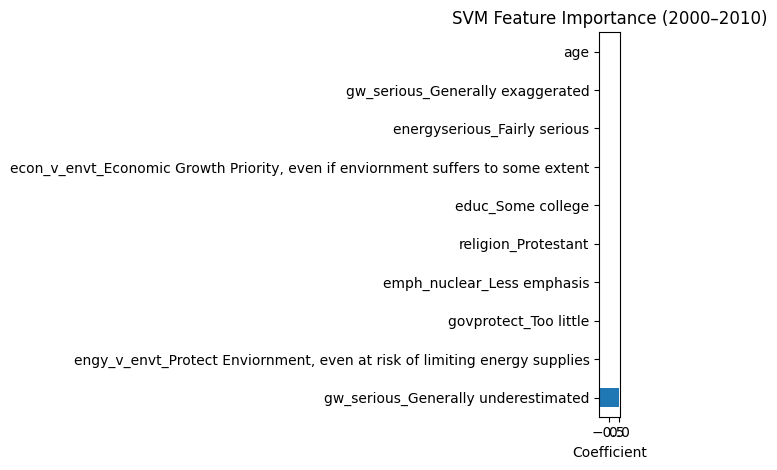


--- Logic Flow (Approximation via Decision Tree) ---


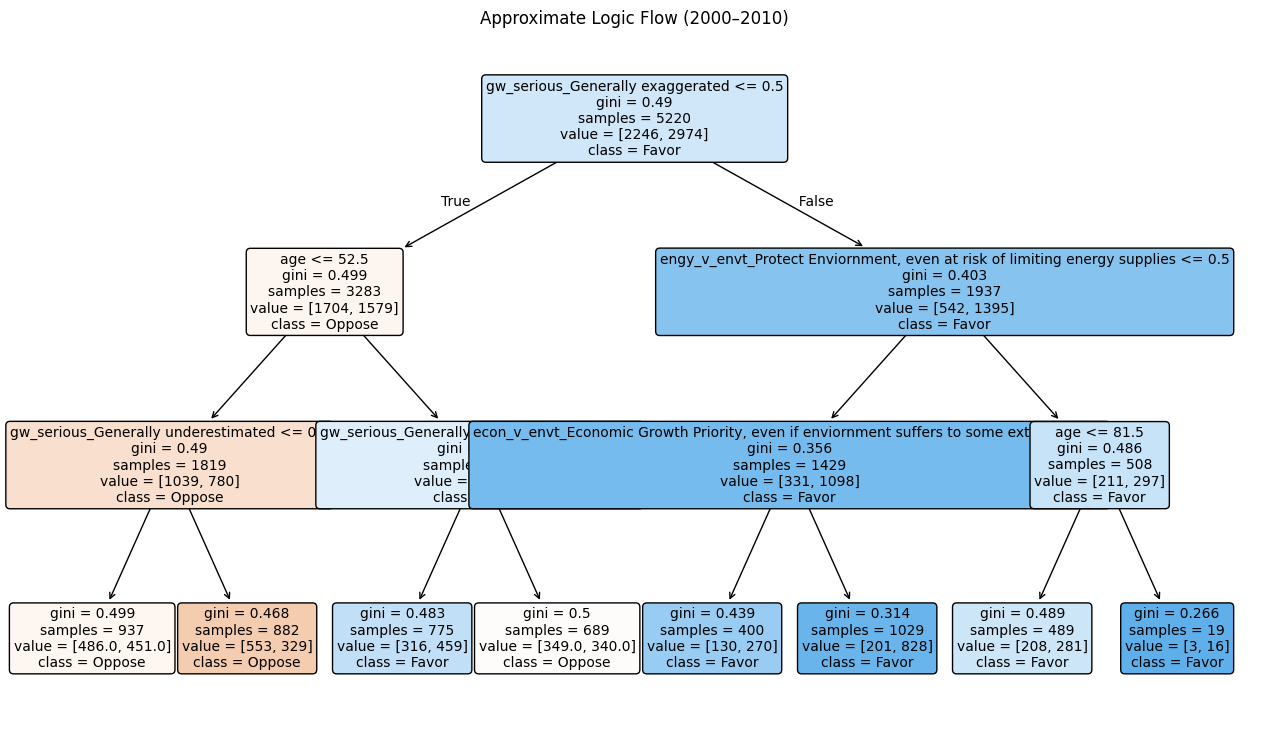


   SVM RESULTS: 2011–2017

Rows in subset: 6735
--- Classification Report ---
              precision    recall  f1-score   support

  Oppose (0)       0.62      0.53      0.57       748
   Favor (1)       0.66      0.74      0.70       936

    accuracy                           0.64      1684
   macro avg       0.64      0.63      0.63      1684
weighted avg       0.64      0.64      0.64      1684

--- Confusion Matrix ---
TN: 395 | FP: 353
FN: 247 | TP: 689

--- Feature Importance (SVM Coefficients) ---
                                             feature  importance
4                gw_serious_Generally underestimated   -0.926745
2                         emph_nuclear_Less emphasis   -0.583170
6  econ_v_envt_Economic Growth Priority, even if ...    0.000177
8                              govprotect_Too little   -0.000153
1                   gw_serious_Generally exaggerated    0.000150
7  engy_v_envt_Protect Enviornment, even at risk ...   -0.000108
9                       energys

<Figure size 800x500 with 0 Axes>

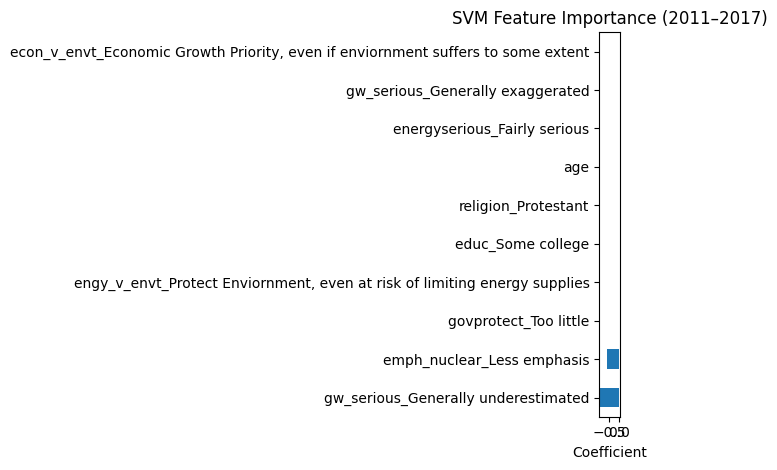


--- Logic Flow (Approximation via Decision Tree) ---


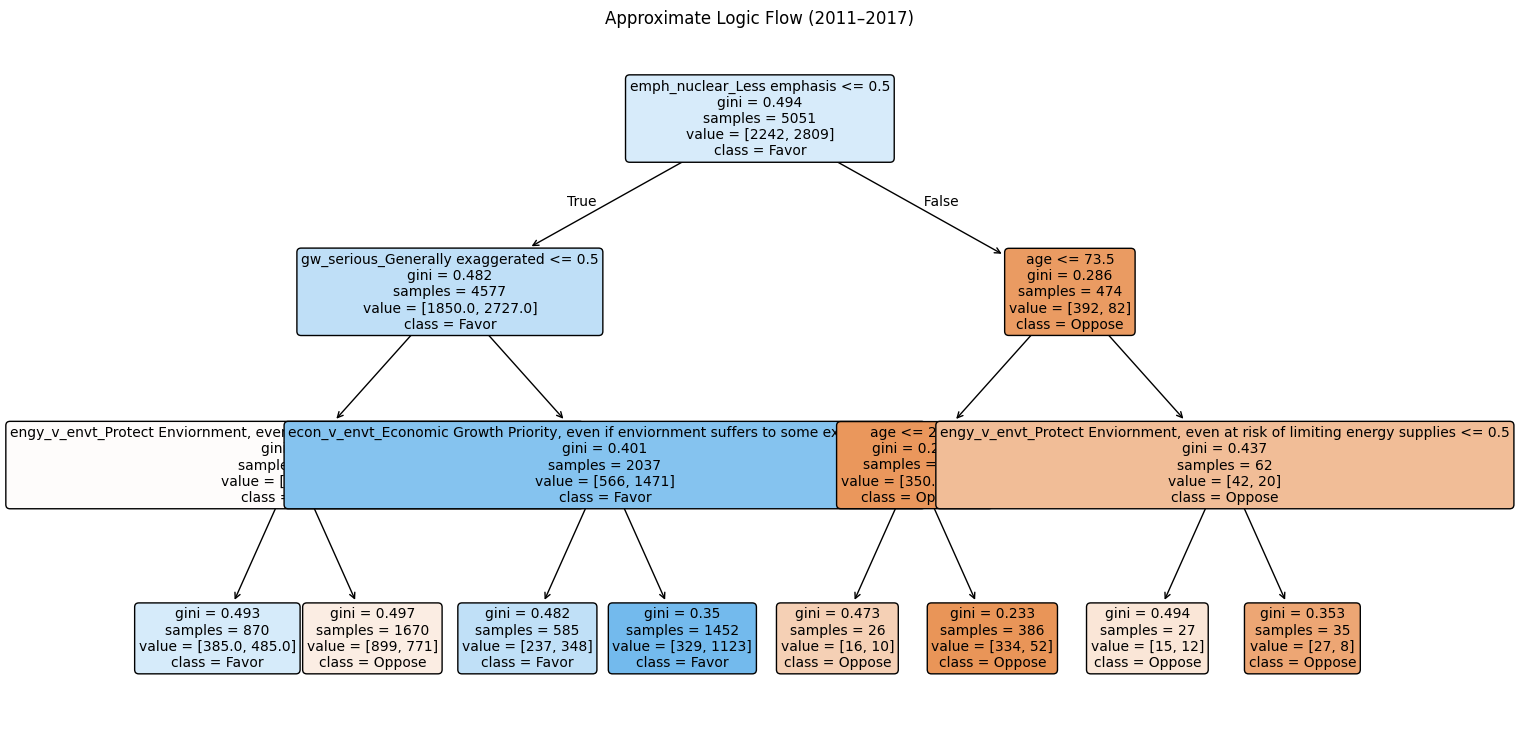


   SVM RESULTS: 2018–2025

Rows in subset: 4410
--- Classification Report ---
              precision    recall  f1-score   support

  Oppose (0)       0.55      0.50      0.53       457
   Favor (1)       0.67      0.71      0.69       646

    accuracy                           0.62      1103
   macro avg       0.61      0.61      0.61      1103
weighted avg       0.62      0.62      0.62      1103

--- Confusion Matrix ---
TN: 230 | FP: 227
FN: 189 | TP: 457

--- Feature Importance (SVM Coefficients) ---
                                             feature  importance
7  engy_v_envt_Protect Enviornment, even at risk ...   -0.948736
2                         emph_nuclear_Less emphasis   -0.394324
1                   gw_serious_Generally exaggerated   -0.000145
4                gw_serious_Generally underestimated   -0.000107
5                                  educ_Some college    0.000046
8                              govprotect_Too little   -0.000040
6  econ_v_envt_Economic Growth 

<Figure size 800x500 with 0 Axes>

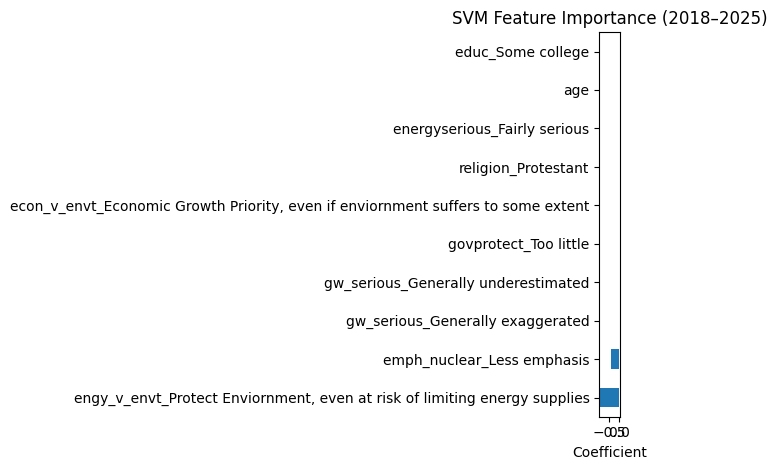


--- Logic Flow (Approximation via Decision Tree) ---


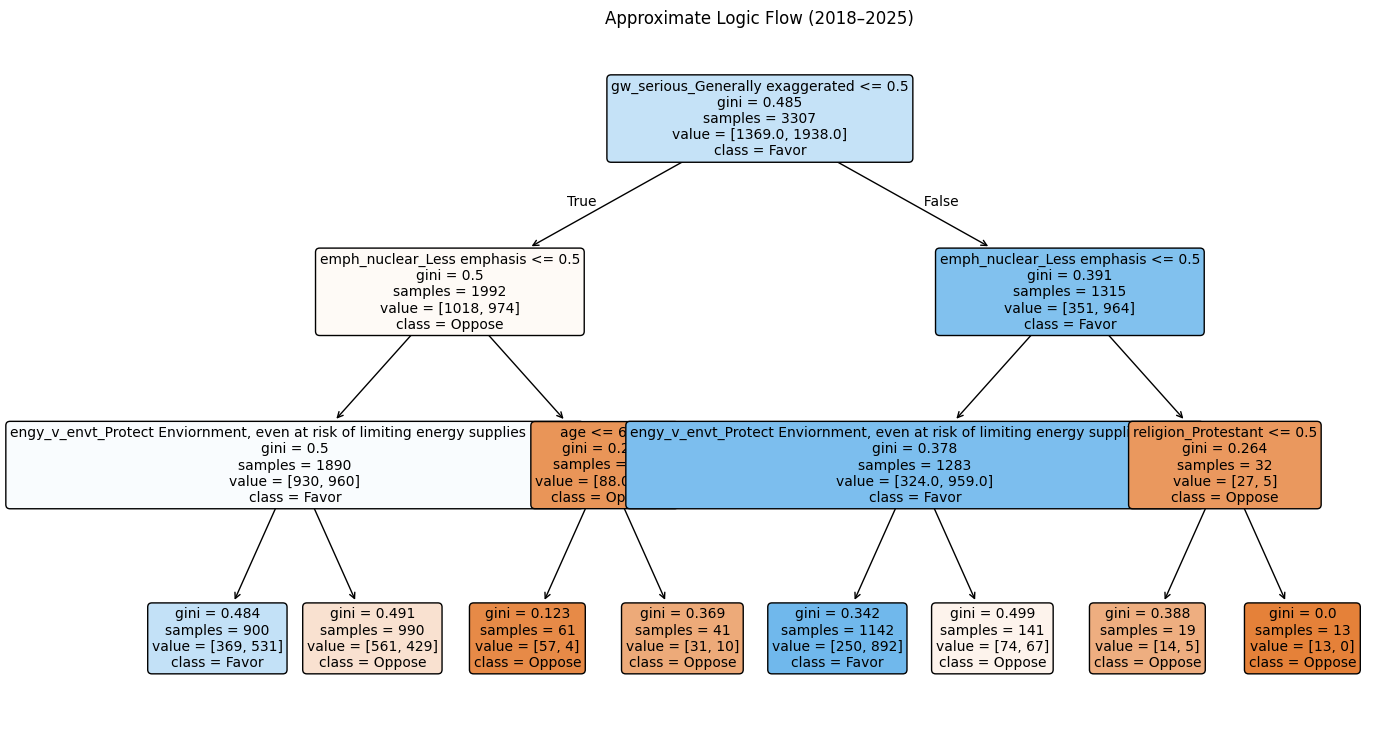

In [17]:
# 2000–2010
run_svm_analysis(df_encoded, (2000, 2010), features)

# 2011–2017
run_svm_analysis(df_encoded, (2011, 2017), features)

# 2018–2025
run_svm_analysis(df_encoded, (2018, 2025), features)

Check target balance by period

In [18]:
for start, end in [(2000, 2010), (2011, 2017), (2018, 2025)]:
    temp = df_encoded[df_encoded['yr'].between(start, end)]
    print(f"\n{start}-{end}")
    print(temp['nuclear_target'].value_counts())


2000-2010
nuclear_target
1    4003
0    3032
Name: count, dtype: int64

2011-2017
nuclear_target
1    3806
0    3039
Name: count, dtype: int64

2018-2025
nuclear_target
1    2623
0    1866
Name: count, dtype: int64


In [19]:
periods = [
    (2000, 2010),
    (2011, 2017),
    (2018, 2025)
]

for start, end in periods:
    temp = df_encoded[df_encoded['yr'].between(start, end)]
    
    counts = temp['nuclear_target'].value_counts().sort_index()
    percentages = temp['nuclear_target'].value_counts(normalize=True).sort_index() * 100
    
    print(f"\n{start}-{end}")
    print("Counts:")
    print(counts)
    
    print("\nPercentages:")
    print(percentages.round(2))


2000-2010
Counts:
nuclear_target
0    3032
1    4003
Name: count, dtype: int64

Percentages:
nuclear_target
0    43.1
1    56.9
Name: proportion, dtype: float64

2011-2017
Counts:
nuclear_target
0    3039
1    3806
Name: count, dtype: int64

Percentages:
nuclear_target
0    44.4
1    55.6
Name: proportion, dtype: float64

2018-2025
Counts:
nuclear_target
0    1866
1    2623
Name: count, dtype: int64

Percentages:
nuclear_target
0    41.57
1    58.43
Name: proportion, dtype: float64


Missing selected features

In [20]:
missing_features = [f for f in features if f not in df_encoded.columns]
print("Missing selected features:", missing_features)

Missing selected features: []


In [21]:
df_model.to_csv("/kaggle/working/fav_nuclear_and_nucfav_combined_labeled_gpss.csv", index=False)